## Import Data

In [2]:
import pandas as pd
df = pd.read_csv('loan_data.csv')
display(df.head())

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## Pemahaman Data (Data Understanding)

Berikut adalah penjelasan untuk setiap kolom dalam dataset `df` Anda:

*   **`person_age`**: Usia pemohon pinjaman. Ini adalah fitur numerik yang kemungkinan akan digunakan untuk menilai risiko.
*   **`person_gender`**: Jenis kelamin pemohon pinjaman (misalnya, 'male', 'female'). Ini adalah fitur kategorikal yang perlu di-*encoding*.
*   **`person_education`**: Tingkat pendidikan pemohon (misalnya, 'Master', 'High School', 'Bachelor'). Ini juga fitur kategorikal yang penting dalam penilaian kelayakan kredit.
*   **`person_income`**: Pendapatan tahunan pemohon pinjaman. Fitur numerik yang sangat krusial dalam menentukan kemampuan membayar pinjaman.
*   **`person_emp_exp`**: Pengalaman kerja pemohon dalam tahun. Semakin tinggi pengalaman, mungkin diasumsikan semakin stabil pendapatannya. Fitur numerik.
*   **`person_home_ownership`**: Status kepemilikan rumah pemohon (misalnya, 'RENT', 'OWN', 'MORTGAGE'). Ini menunjukkan stabilitas finansial dan akan menjadi fitur kategorikal.
*   **`loan_amnt`**: Jumlah pinjaman yang diminta. Fitur numerik ini adalah variabel target utama jika kita ingin memprediksi jumlah pinjaman, tetapi dalam klasifikasi, ini adalah fitur masukan.
*   **`loan_intent`**: Tujuan dari pinjaman (misalnya, 'PERSONAL', 'EDUCATION', 'MEDICAL'). Ini adalah fitur kategorikal yang bisa mengungkapkan risiko atau kebutuhan yang berbeda.
*   **`loan_int_rate`**: Tingkat suku bunga pinjaman. Fitur numerik yang secara langsung memengaruhi biaya pinjaman dan merupakan indikator risiko.
*   **`loan_percent_income`**: Rasio jumlah pinjaman terhadap pendapatan tahunan pemohon. Ini adalah metrik penting untuk mengukur beban utang relatif. Fitur numerik.
*   **`cb_person_cred_hist_length`**: Panjang riwayat kredit pemohon dalam tahun. Umumnya, riwayat kredit yang lebih panjang dan baik menunjukkan peminjam yang lebih bertanggung jawab. Fitur numerik.
*   **`credit_score`**: Skor kredit pemohon. Ini adalah indikator langsung dari kelayakan kredit pemohon. Fitur numerik.
*   **`previous_loan_defaults_on_file`**: Apakah pemohon memiliki catatan *default* pinjaman sebelumnya (misalnya, 'Yes', 'No'). Ini adalah fitur kategorikal yang sangat prediktif terhadap risiko di masa depan.
*   **`loan_status`**: Status pinjaman (0 atau 1). Ini adalah **variabel target** utama kita. Kemungkinan 1 = disetujui, 0 = ditolak (atau sebaliknya). Ini adalah fitur biner kategorikal untuk klasifikasi.

## Memeriksa Missing Values

In [4]:
print(df.isnull().sum())

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


## Cek Tipe Data per Kolom

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

## Encoding Variabel Kategorikal

Algoritma machine learning membutuhkan input numerik. Kita akan mengubah kolom kategorikal menjadi numerik menggunakan One-Hot Encoding. Kita akan menggunakan drop_first=True untuk menghindari multicollinearity.

In [7]:
categorical_cols = [
    'person_gender',
    'person_education',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]

#Menerapkan One-Hot Encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print('\nDataFrame setelah encoding')
print(df.head())
print(f'Jumlah kolom baru: {df.shape[1]}')


DataFrame setelah encoding
   person_age  person_income  person_emp_exp  loan_amnt  loan_int_rate  \
0        22.0        71948.0               0    35000.0          16.02   
1        21.0        12282.0               0     1000.0          11.14   
2        25.0        12438.0               3     5500.0          12.87   
3        23.0        79753.0               0    35000.0          15.23   
4        24.0        66135.0               1    35000.0          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  loan_status  \
0                 0.49                         3.0           561            1   
1                 0.08                         2.0           504            0   
2                 0.44                         3.0           635            1   
3                 0.44                         2.0           675            1   
4                 0.53                         4.0           586            1   

   person_gender_male  ...  person_educa

## Pemisahan Fitur Target

Kita perlu memisahkan data menjadi fitur (X) yang akan digunakan untuk membuat prediksi, dan variabel target (y) yang ingin kita prediksi (loan_status).

In [8]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

print('\nShape dari fitur (X):', X.shape)
print('Shape dari target (y):', y.shape)


Shape dari fitur (X): (45000, 22)
Shape dari target (y): (45000,)


## Pembagian Data Training dan Testing

Untuk melatih dan mengevaluasi model secara objektif, kita akan membagi dataset menjadi set pelatihan (training set) dan set pengujian (test set). Kita akan menggunakan stratify=y untuk memastikan distribusi kelas target (loan_status) yang seimbang di kedua set.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('\nShape dari X_train', X_train.shape)
print('Shape dari y_train:', y_train.shape)
print('Shape dari X_test:', X_test.shape)
print('Shape dari y_test:', y_test.shape)



Shape dari X_train (36000, 22)
Shape dari y_train: (36000,)
Shape dari X_test: (9000, 22)
Shape dari y_test: (9000,)


## Penskalaan Fitur (Featue Scaling)

Regresi Logistik, seperti banyak model berbasis gradien lainnya, sangat sensitif terhadap skala fitur. Oleh karena itu, penting untuk melakukan penskalaan fitur numerik. Kita akan menggunakan StandardScaler untuk menstandardisasi fitur, membuat rata-ratanya nol dan variansnya satu. Ini harus diterapkan hanya pada fitur numerik di X_train dan X_test.

In [10]:
from sklearn.preprocessing import StandardScaler

#Identifikasi kolom numerik
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

#Inisialisasi StandardScaler
scaler = StandardScaler()

#Feature Scaling pada data training
X_train_scaled = scaler.fit_transform(X_train[numeric_cols])

#Feature Scaling pada data testing
X_test_scaled = scaler.transform(X_test[numeric_cols])

# Ubah array yang diskalakan kembali menjadi DataFrame dengan nama kolom asli
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numeric_cols, index=X_test.index)

print("Fitur berhasil diskalakan.")
print(f"Shape dari X_train_scaled: {X_train_scaled.shape}")
print(f"Shape dari X_test_scaled: {X_test_scaled.shape}")

Fitur berhasil diskalakan.
Shape dari X_train_scaled: (36000, 8)
Shape dari X_test_scaled: (9000, 8)


## Model Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(random_state=42, solver='liblinear')
model_lr.fit(X_train_scaled, y_train)

print("Model Logistic Regression berhasil dilatih.")

Model Logistic Regression berhasil dilatih.


## Evaluasi Model

Setelah model dilatih, kita akan mengevaluasi performanya menggunakan data pengujian. Kita akan melihat metrik seperti akurasi, presisi, recall, F1-score, dan ROC AUC, serta memvisualisasikan Confusion Matrix.


Metrik Evaluasi Model Logistic Regression: 
Accuracy: 0.83
Precision: 0.69
Recall: 0.40
F1-Score: 0.51
ROC AUC Score: 0.84


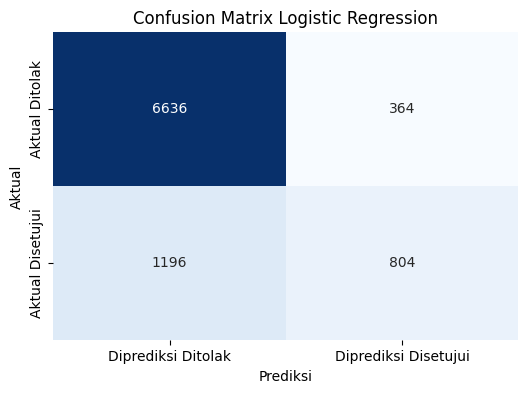

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Lakukan prediksi pada data testing
y_pred = model_lr.predict(X_test_scaled)
y_pred_proba = model_lr.predict_proba(X_test_scaled)[:, 1]

#Hitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f'\nMetrik Evaluasi Model Logistic Regression: ')
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1-Score: {f1:.2f}')
print(f'ROC AUC Score: {roc_auc:.2f}')

#Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Diprediksi Ditolak', 'Diprediksi Disetujui'],
            yticklabels=['Aktual Ditolak', 'Aktual Disetujui'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Logistic Regression')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

## Insight dari Model Logistic Regression

Berdasarkan hasil evaluasi model Regresi Logistik untuk prediksi status persetujuan pinjaman, kita dapat memperoleh insight sebagai berikut:

*   **Akurasi (Accuracy): 0.83**
    *   Model secara keseluruhan memprediksi status pinjaman dengan benar sebesar 83%. Ini menunjukkan performa dasar yang cukup baik. Namun, akurasi saja bisa misleading pada dataset yang tidak seimbang.

*   **Presisi (Precision): 0.69**
    *   Dari semua kasus yang diprediksi model sebagai `disetujui`, 69% di antaranya benar-benar `disetujui`. Metrik ini penting untuk meminimalkan *False Positives* (pinjaman yang diprediksi disetujui tetapi sebenarnya harus ditolak), yang dapat mengurangi risiko kerugian bagi pemberi pinjaman.

*   **Recall (Recall): 0.40**
    *   Dari semua pinjaman yang **seharusnya** `disetujui`, model hanya berhasil mengidentifikasi 40% di antaranya. Ini berarti model memiliki *False Negatives* yang cukup tinggi (pinjaman yang seharusnya disetujui malah diprediksi ditolak). Recall yang rendah mengindikasikan bahwa model mungkin melewatkan banyak pemohon pinjaman yang sebenarnya layak, yang bisa berujung pada hilangnya potensi bisnis.

*   **F1-Score: 0.51**
    *   F1-Score memberikan keseimbangan antara Presisi dan Recall. Nilai 0.51 menunjukkan bahwa ada ruang signifikan untuk perbaikan dalam menyeimbangkan kemampuan model untuk menghindari *False Positives* dan *False Negatives* secara bersamaan.

*   **ROC AUC Score: 0.84**
    *   Skor ROC AUC sebesar 0.84 adalah indikator yang kuat bahwa model memiliki kemampuan diskriminasi yang baik; ia mampu membedakan dengan cukup efektif antara kelas 'disetujui' dan 'ditolak'. Nilai ini jauh lebih baik dari tebakan acak (0.5), menunjukkan bahwa model memang belajar pola yang berarti dari data.

### Implikasi dan Rekomendasi:

Model Regresi Logistik ini menunjukkan **kemampuan prediksi yang layak secara keseluruhan** (terutama dilihat dari Akurasi dan ROC AUC). Namun, **nilai Recall yang relatif rendah** adalah perhatian utama. Tergantung pada tujuan bisnis:

*   **Jika fokus utama adalah mengurangi risiko (menghindari kerugian dari pinjaman yang salah disetujui):** Model ini bekerja cukup baik dengan presisi 69%, artinya ketika model merekomendasikan persetujuan, ada kemungkinan besar itu keputusan yang benar.
*   **Jika fokus utama adalah memaksimalkan akuisisi pelanggan yang layak (tidak melewatkan pemohon yang baik):** Recall yang rendah menunjukkan model perlu ditingkatkan untuk mengidentifikasi lebih banyak pinjaman yang seharusnya disetujui. Ini penting agar tidak kehilangan peluang bisnis yang menguntungkan.

**Langkah Selanjutnya yang Disarankan:**

1.  **Penanganan Ketidakseimbangan Kelas:** Jika ada ketidakseimbangan kelas dalam variabel target (`loan_status`), pertimbangkan teknik *resampling* seperti SMOTE untuk meningkatkan Recall.
2.  **Eksplorasi Model Lain:** Coba model klasifikasi lain yang mungkin lebih kuat atau lebih baik dalam menangani pola data yang kompleks, seperti Random Forest atau Gradient Boosting Machines (XGBoost/LightGBM).
3.  **Optimalisasi Hyperparameter:** Lakukan *tuning hyperparameter* untuk model Regresi Logistik ini atau model lain yang akan dicoba untuk menemukan konfigurasi terbaik.
4.  **Rekayasa Fitur:** Telusuri lebih lanjut kemungkinan rekayasa fitur untuk menciptakan variabel baru yang mungkin lebih prediktif.